# Notebook for Batch Loading, Sorting, and Plotting the output of PDFgetx3

In [2]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd 
from scipy.ndimage import gaussian_filter1d

import trxrd

%matplotlib widget

## Define Path and Scan Name

In [3]:
DATA_PATH   = Path(r"C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\BTO_18keV\BTO400nmS3_360Klong\output")  # Path to directory containing .gr files
SCAN_NAME  = "BTO400nmS3_360Klong" # filename prefix; set None to load all .dat files

## Load the Data

In [4]:
# Main diffraction data folder
data_path = DATA_PATH

# Check number of files in folder 
file_names = sorted(data_path.glob(f"{SCAN_NAME}*.gr"))
print(f"{len(file_names)} TIFF files found in {data_path}.")

557 TIFF files found in C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\BTO_18keV\BTO400nmS3_360Klong\output.


589 .gr files found in C:\Users\lheald\Documents\Guzelturk_Lab\Cotts_Processed_Data\BTO_18keV\BTO400nmS3_360Klong\output


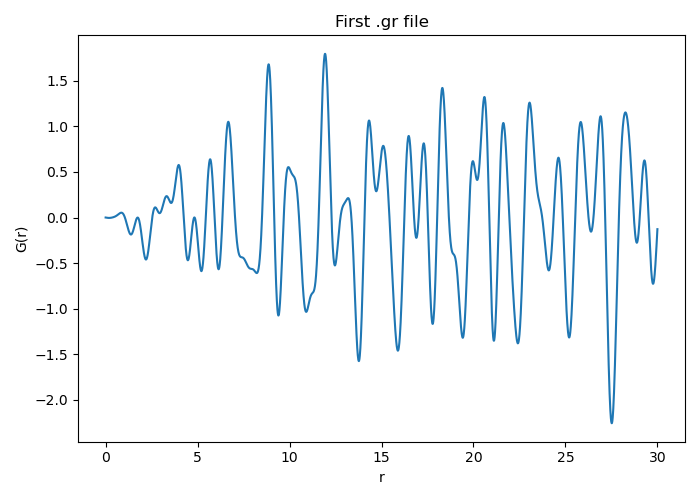

In [5]:
gr_dict = trxrd.get_gr_details(
    folder_path=DATA_PATH,
    sample_name=SCAN_NAME,
    filename_scheme="delay_scan",
    sort=True,
    filter_data=False,
    delay_sign=-1,
    plot=True,
)

r = gr_dict["r"]           # shape (Nr,)
grs = gr_dict["grs"]       # shape (Nfiles, Nr)
delay = gr_dict["delay"]   # shape (Nfiles,)

# gr_dict = trxrd.get_grs_by_scan_name(
#     folder_path=DATA_PATH)

## Compute Reference G(r) and Make dG(r)s

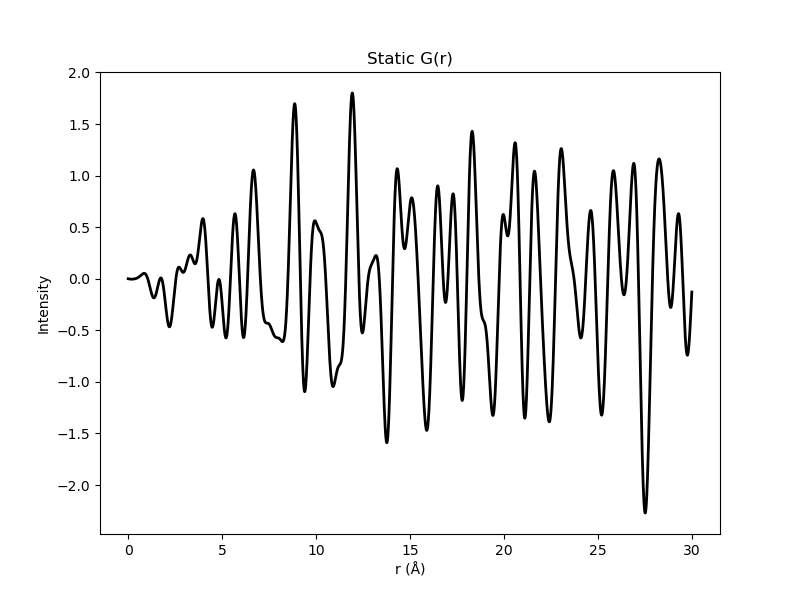

In [8]:
ref_result = trxrd.make_reference_gr(
    grs=gr_dict["grs"],
    delays=gr_dict["delay"],
    reference_selector=None,   # defaults to delays < 0
    return_dict=True,
)

delta_result = trxrd.compute_delta_grs(
    grs=gr_dict["grs"],
    reference_gr=ref_result["reference_gr"],
    mode="subtract",
    delays=gr_dict["delay"],
    r=gr_dict["r"],
    file_names=gr_dict["file_names"],
    scan_number=gr_dict["scan_number"],
    sample_name=gr_dict["sample_name"],
    fluence=gr_dict["fluence"],
    return_dict=True,
)

delta_grs = delta_result["delta_grs"]
reference_gr = ref_result["reference_gr"]

plt.figure(figsize=(8, 6))
plt.plot(gr_dict["r"], reference_gr, label="Reference GR", color="black", linewidth=2)
plt.xlabel("r (Å)")
plt.ylabel("Intensity")
plt.title("Static G(r)")
plt.show()

In [80]:
# np.savetxt(f"{SCAN_NAME}_reference_gr.txt", np.column_stack((r, reference_gr)), header="r\tg(r)")

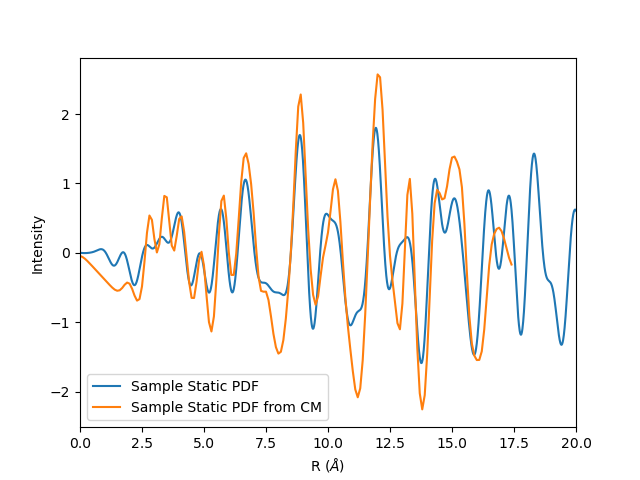

In [11]:
r_vals_cm, pdf_vals_cm = np.loadtxt("BaTiO3 tetragonal.txt", skiprows=3, unpack=True)


dr = r_vals_cm[1] - r_vals_cm[0]
pdf_smooth_cm = gaussian_filter1d(pdf_vals_cm, sigma=2)


plt.figure()
plt.plot(r, reference_gr, label="Sample Static PDF")
plt.plot(r_vals_cm, pdf_smooth_cm/10, label="Sample Static PDF from CM")
plt.xlim(0,20)
plt.xlabel(r"R ($\AA$)")
plt.ylabel("Intensity")
plt.legend()
plt.show()

## Average by Delay

In [12]:
avg_dgr_dict = trxrd.average_delta_grs_by_delay(delta_result, return_dict=True)

print(avg_dgr_dict.keys())
print("Grouped G(r) shape:", avg_dgr_dict["delta_grs"].shape)
print("Grouped std shape:", avg_dgr_dict["std_delta_grs"].shape)
print("Unique delays:", avg_dgr_dict["delay"])
print("Counts per delay:", avg_dgr_dict["counts_per_delay"])

dict_keys(['delta_grs', 'std_delta_grs', 'delay', 'counts_per_delay', 'indices_by_delay', 'grouped_file_names', 'grouped_scan_numbers', 'r'])
Grouped G(r) shape: (32, 3001)
Grouped std shape: (32, 3001)
Unique delays: [-8.000e-08 -1.000e-08 -5.000e-09  2.000e-10  4.000e-10  6.000e-10
  8.000e-10  1.000e-09  2.000e-09  3.500e-09  5.000e-09  1.000e-08
  2.000e-08  3.000e-08  4.000e-08  5.000e-08  6.000e-08  8.000e-08
  1.000e-07  1.500e-07  2.500e-07  3.750e-07  5.000e-07  7.500e-07
  1.000e-06  1.626e-06  2.688e-06  3.750e-06  5.000e-06  7.500e-06
  1.000e-05  1.350e-05]
Counts per delay: [17 18 18 17 17 17 18 18 18 18 17 18 18 18 17 17 18 17 18 17 17 18 17 17
 17 17 17 17 18 17 17 17]


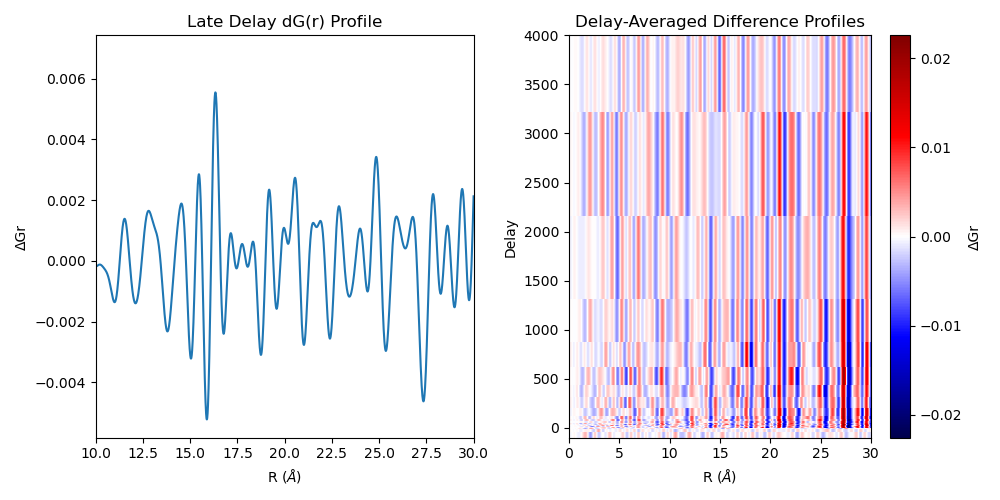

In [14]:
# Plot Heatmap of mean profiles vs delay
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.plot(avg_dgr_dict["r"], avg_dgr_dict["delta_grs"][-1], label="Mean Profile")
plt.xlim(10,30)
plt.xlabel(r"R ($\AA$)")
plt.ylabel("ΔGr")       
plt.title("Late Delay dG(r) Profile")

plt.subplot(1,2,2)
plt.pcolormesh(avg_dgr_dict["r"], avg_dgr_dict["delay"]*1e9, avg_dgr_dict["delta_grs"], shading="auto", cmap="seismic")
plt.colorbar(label="ΔGr")

#plt.ylim(-2e-8, 1e-8)
plt.clim(-np.nanmax(avg_dgr_dict["delta_grs"]), np.nanmax(avg_dgr_dict["delta_grs"]))  # set color limits for better contrast; adjust as needed
plt.xlabel(r"R ($\AA$)")
plt.ylabel("Delay")
plt.title("Delay-Averaged Difference Profiles")
plt.ylim(-100, 4000)
plt.tight_layout()
plt.show()

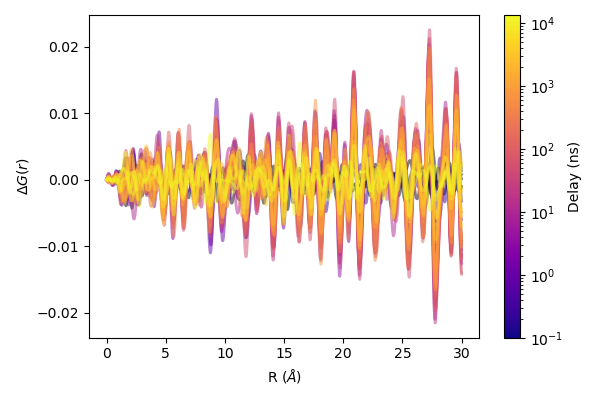

In [15]:
r = avg_dgr_dict["r"]

delays = avg_dgr_dict["delay"]*1e9 # ns
indices = np.arange(0, len(delays))

# Use log scale but handle negative delay separately
norm = mcolors.LogNorm(vmin=0.1, vmax=delays.max())
cmap = cm.plasma

fig, ax = plt.subplots(figsize=(6,4))

for i, d in enumerate(delays):
    # handle negative delay (plot in gray or separate color)
    if d < 0:
        color = "black"
    else:
        color = cmap(norm(d))
    
    ax.plot(
        r,
        avg_dgr_dict["delta_grs"][indices[i]],
        color=color,
        alpha=0.5,
        linewidth=2,
        label=f"{d} ns"
    )

# Proper colorbar attachment
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # required for matplotlib
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Delay (ns)")

ax.set_xlabel(r"R ($\AA$)")
ax.set_ylabel(r"$\Delta G(r)$")
# ax.legend()
# ax.set_xlim(0, 5)
# ax.set_ylim(-0.01, 0.01)

plt.tight_layout()
plt.show()

## SVD Analysis

Matrix shape: (3001, 32)
Singular values (dI): [1.20682139 0.2452055  0.14856051 0.13921036 0.12788653]
Variance explained: [0.83465356 0.03445725 0.01264815 0.01110615 0.00937281]


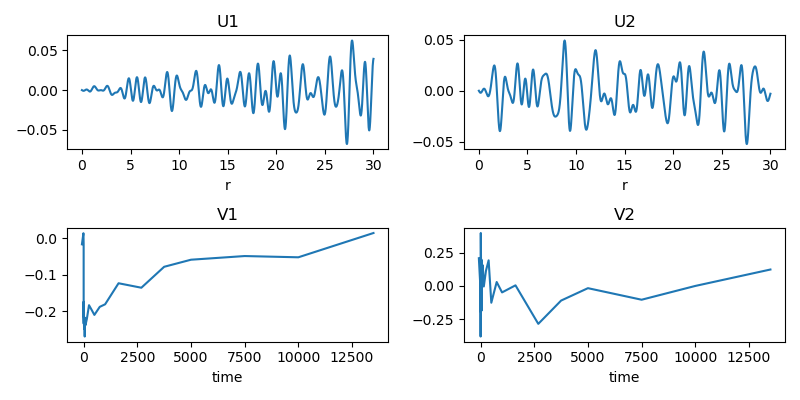

In [16]:
matrix = avg_dgr_dict["delta_grs"].T
print("Matrix shape:", matrix.shape)

svd_result = trxrd.svd_analysis(
    data=matrix,
    axis_values=r,
    time_values=delays
)

# Inspect
print("Singular values (dI):", svd_result['S'][:5])
print("Variance explained:", svd_result['variance_explained'][:5])

# Plot first two components

fig, axes = plt.subplots(2, 2, figsize=(8, 4))
for i in range(2):
    axes[0, i].plot(r, svd_result['U'][:, i])
    axes[0, i].set_xlabel('r'); axes[0, i].set_title(f'U{i+1}')
    axes[1, i].plot(delays, svd_result['Vt'][i, :])
    axes[1, i].set_xlabel('time'); axes[1, i].set_title(f'V{i+1}')
plt.tight_layout()

## Comparing Results with Calculated PDFs by my Code

In [39]:
df = pd.read_csv("BaTiO3_deltaGr_profile.csv")
df.keys()

Index(['r', 'dGr_late', 'dGr_early'], dtype='str')

In [40]:
delays

array([-80. ,  -5. ,   0.6])

IndexError: index 4 is out of bounds for axis 0 with size 3

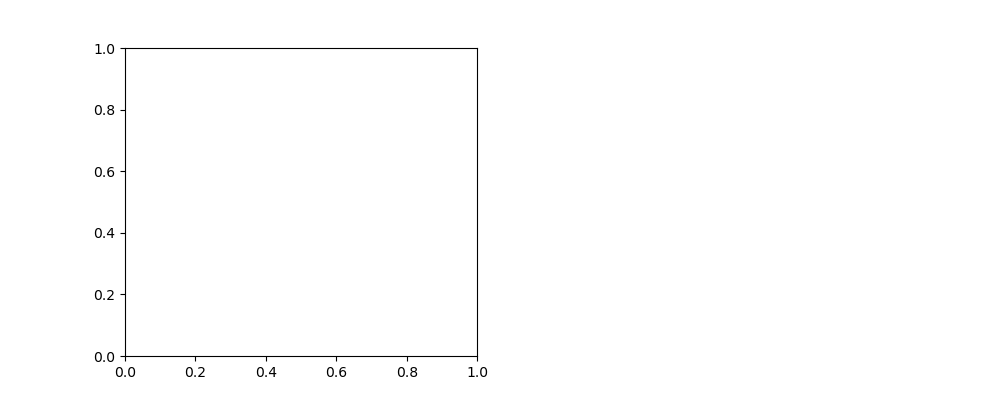

In [41]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
# plt.plot(df["r"], df["dGr_late"]*6, label="dG(r) Lauren 100 ns")
# plt.plot(df["r"], df["dGr_0"]*10, label="Early Calculated dG(r) Lauren")
plt.plot(avg_dgr_dict["r"], avg_dgr_dict["delta_grs"][4]*1, label="dG(r)")
plt.plot(avg_dgr_dict["r"], -svd_result['U'][:, 0], label="SVD Component 1 (scaled)")
# plt.plot(avg_dgr_dict["r"], avg_dgr_dict["delta_grs"][0], label="Early dG(r) from PDFgetX3")
plt.xlabel("r")
plt.ylabel("dGr")
plt.legend()
plt.xlim(0, 30)

plt.subplot(1,2,2)
plt.plot(avg_dgr_dict["r"], avg_dgr_dict["delta_grs"][4]*1, label="dG(r)")
plt.plot(avg_dgr_dict["r"], svd_result['U'][:, 1], label="SVD Component 2 (scaled)")

plt.xlabel("r")
plt.ylabel("dGr")
plt.legend()
plt.xlim(0, 30)
plt.tight_layout()
plt.show()

## Average G(r) by Delay

In [17]:
avg_gr_dict = trxrd.average_profiles_by_delay(grs, delay, return_dict=True)


for i, profile in enumerate(avg_gr_dict["mean_profiles"]):
    np.savetxt(DATA_PATH/f"BaTiO3_{delays[i]}_gr.gr", np.column_stack((r, profile)), header="r\tg(r)")



Delay -8e-08: 17 profiles averaged
Delay -1e-08: 18 profiles averaged
Delay -5e-09: 18 profiles averaged
Delay 2e-10: 17 profiles averaged
Delay 4e-10: 17 profiles averaged
Delay 6e-10: 17 profiles averaged
Delay 8e-10: 18 profiles averaged
Delay 1e-09: 18 profiles averaged
Delay 2e-09: 18 profiles averaged
Delay 3.5e-09: 18 profiles averaged
Delay 5e-09: 17 profiles averaged
Delay 1e-08: 18 profiles averaged
Delay 2e-08: 18 profiles averaged
Delay 3e-08: 18 profiles averaged
Delay 4e-08: 17 profiles averaged
Delay 5e-08: 17 profiles averaged
Delay 6e-08: 18 profiles averaged
Delay 8e-08: 17 profiles averaged
Delay 1e-07: 18 profiles averaged
Delay 1.5e-07: 17 profiles averaged
Delay 2.5e-07: 17 profiles averaged
Delay 3.75e-07: 18 profiles averaged
Delay 5e-07: 17 profiles averaged
Delay 7.5e-07: 17 profiles averaged
Delay 1e-06: 17 profiles averaged
Delay 1.626e-06: 17 profiles averaged
Delay 2.688e-06: 17 profiles averaged
Delay 3.75e-06: 17 profiles averaged
Delay 5e-06: 18 profile

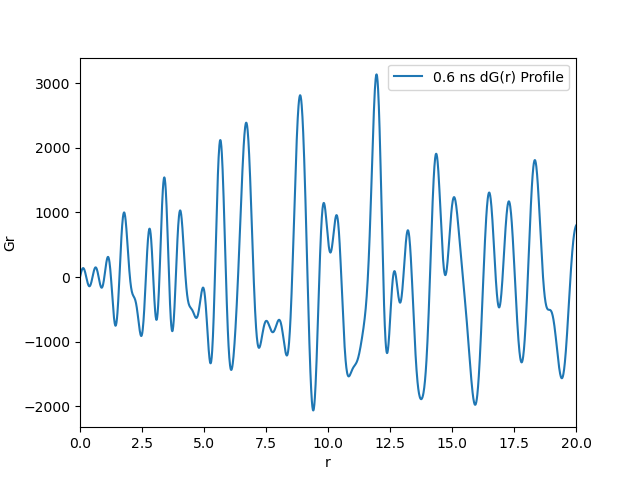

In [54]:
plt.figure()
plt.plot(r, avg_gr_dict["mean_profiles"][2]*500, label=f"{delays[2]} ns dG(r) Profile")
plt.xlabel("r")
plt.ylabel("Gr")
plt.legend()
plt.xlim(0, 20)
plt.show()